In [1]:
# ============================================================
# Student Performance Prediction
# Author: Gabriel Villarreal
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

In [2]:
# Load dataset
df = pd.read_csv("../data/raw/StudentPerformanceFactors.csv")

# Display first rows
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [3]:
# Dataset dimensions
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 6607
Columns: 20


In [4]:
# Dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

In [5]:
# Statistical summary
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [6]:
# Missing values
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [7]:
# Duplicate rows
df.duplicated().sum()

np.int64(0)

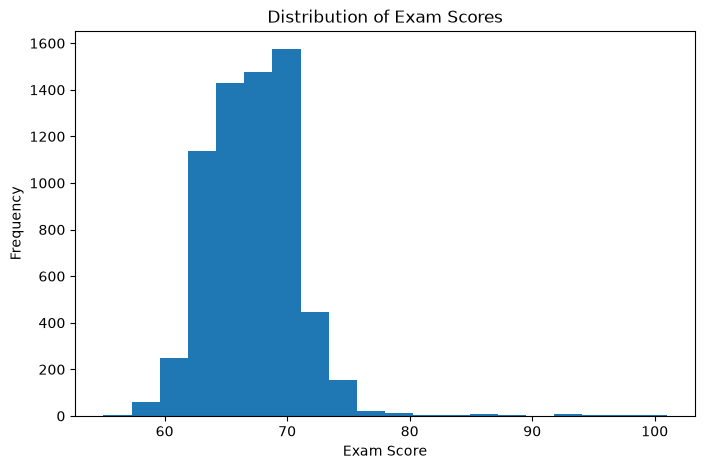

In [8]:
plt.figure(figsize=(8,5))

plt.hist(df["Exam_Score"], bins=20)

plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Frequency")

plt.show()

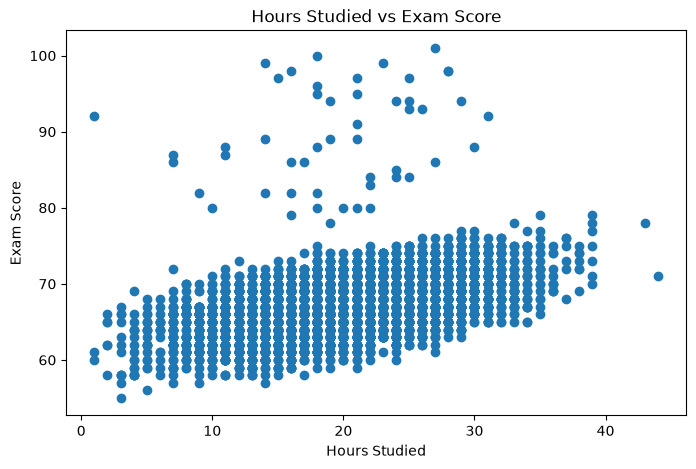

In [9]:
plt.figure(figsize=(8,5))

plt.scatter(df["Hours_Studied"], df["Exam_Score"])

plt.title("Hours Studied vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")

plt.show()

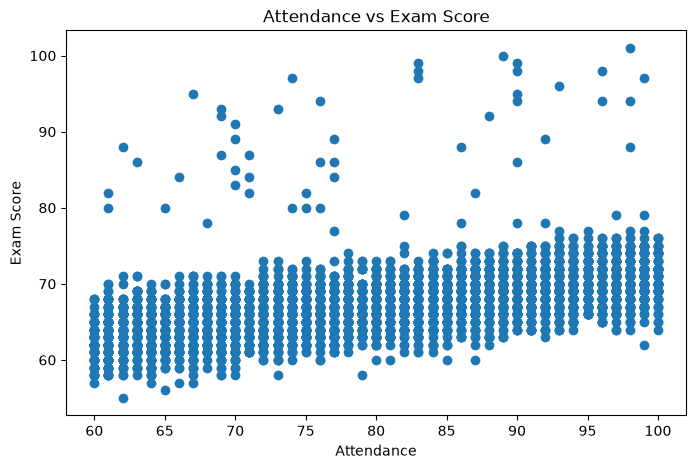

In [10]:
plt.figure(figsize=(8,5))

plt.scatter(df["Attendance"], df["Exam_Score"])

plt.title("Attendance vs Exam Score")
plt.xlabel("Attendance")
plt.ylabel("Exam Score")

plt.show()

In [11]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

In [12]:
numeric_df.corr()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
Hours_Studied,1.000000,-0.009908,0.010977,0.024846,-0.014282,0.004624,0.445455
Attendance,-0.009908,1.000000,-0.015918,-0.020186,0.014324,-0.022435,0.581072
Sleep_Hours,0.010977,-0.015918,1.000000,-0.021750,-0.012216,-0.000378,-0.017022
Previous_Scores,0.024846,-0.020186,-0.021750,1.000000,-0.013122,-0.011274,0.175079
Tutoring_Sessions,-0.014282,0.014324,-0.012216,-0.013122,1.000000,0.017733,0.156525
Physical_Activity,0.004624,-0.022435,-0.000378,-0.011274,0.017733,1.000000,0.027824
Exam_Score,0.445455,0.581072,-0.017022,0.175079,0.156525,0.027824,1.000000


In [13]:
X = df.drop("Exam_Score", axis=1)
y = df["Exam_Score"]

print(X.shape)
print(y.shape)

(6607, 19)
(6607,)


In [14]:
X.dtypes

Hours_Studied                 int64
Attendance                    int64
Parental_Involvement            str
Access_to_Resources             str
Extracurricular_Activities      str
Sleep_Hours                   int64
Previous_Scores               int64
Motivation_Level                str
Internet_Access                 str
Tutoring_Sessions             int64
Family_Income                   str
Teacher_Quality                 str
School_Type                     str
Peer_Influence                  str
Physical_Activity             int64
Learning_Disabilities           str
Parental_Education_Level        str
Distance_from_Home              str
Gender                          str
dtype: object

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

In [16]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns

categorical_features = X.select_dtypes(include=["object"]).columns

print("Numeric columns:")
print(numeric_features)

print("\nCategorical columns:")
print(categorical_features)

Numeric columns:
Index(['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
       'Tutoring_Sessions', 'Physical_Activity'],
      dtype='str')

Categorical columns:
Index(['Parental_Involvement', 'Access_to_Resources',
       'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access',
       'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence',
       'Learning_Disabilities', 'Parental_Education_Level',
       'Distance_from_Home', 'Gender'],
      dtype='str')


C:\Users\gabyn\AppData\Local\Temp\ipykernel_11236\2119771465.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns


In [17]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessor created successfully!")

Preprocessor created successfully!


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (5285, 19)
Testing samples: (1322, 19)


In [19]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

print("Model created successfully!")

Model created successfully!


In [20]:
model.fit(X_train, y_train)

print("Training completed!")

Training completed!


In [21]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[64.52628302 65.2651138  71.53126265 64.27748146 66.5216532  66.61246339
 72.47094891 66.49826901 69.98604472 70.13327106]


In [22]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

MAE : 0.45
RMSE: 1.80
R²  : 0.7696


In [23]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results.head(10)

,Actual,Predicted
0,65,64.526283
1,65,65.265114
2,71,71.531263
3,64,64.277481
4,66,66.521653
5,66,66.612463
6,72,72.470949
7,66,66.498269
8,70,69.986045
9,70,70.133271


In [24]:
joblib.dump(model, "../models/student_performance_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [25]:
results.to_csv("../processed/predictions.csv", index=False)

print("Predictions saved!")

OSError: Cannot save file into a non-existent directory: '..\processed'

In [26]:
results.to_csv("../data/processed/predictions.csv", index=False)